In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df=pd.read_csv('census-income .csv')

In [44]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [50]:
df[(df['occupation']=='?') | (df['workclass']=='?') | (df['native-country']=='?')]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
14,40,Private,121772,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,Asian-Pac-Islander,Male,0,0,40,?,>50K
27,54,?,180211,Some-college,10,Married-civ-spouse,?,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
38,31,Private,84154,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,38,?,>50K
51,18,Private,226956,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,30,?,<=50K
61,32,?,293936,7th-8th,4,Married-spouse-absent,?,Not-in-family,White,Male,0,0,40,?,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32530,35,?,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,>50K
32531,30,?,33811,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
32539,71,?,287372,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,0,0,10,United-States,>50K
32541,41,?,202822,HS-grad,9,Separated,?,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [52]:
df['workclass']=df['workclass'].replace('?',np.nan)
df['occupation']=df['occupation'].replace('?',np.nan)
df['native-country']=df['native-country'].replace('?',np.nan)

In [54]:
df[(df['workclass']=='?') | (df['occupation']=='?') | (df['native-country']=='?')]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income


In [64]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
annual_income        0
dtype: int64

In [66]:
df['workclass']=df['workclass'].fillna(df['workclass'].mode()[0])
df['occupation']=df['occupation'].fillna(df['occupation'].mode()[0])
df['native-country']=df['native-country'].fillna(df['native-country'].mode()[0])

In [68]:
df.isnull().sum()


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
annual_income     0
dtype: int64

In [70]:
df.duplicated().sum()

24

In [72]:
df.drop_duplicates(inplace=True)

In [76]:
df.duplicated().sum()

0

In [94]:
df.shape

(21722, 15)

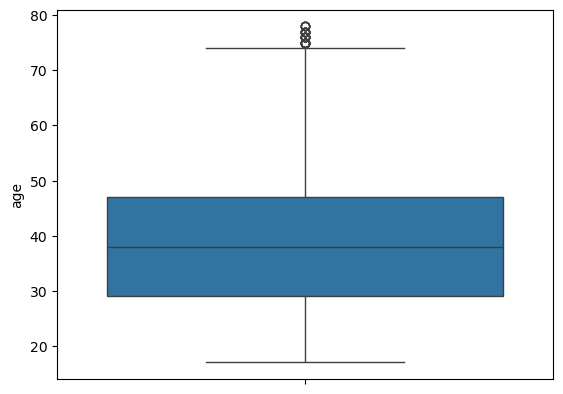

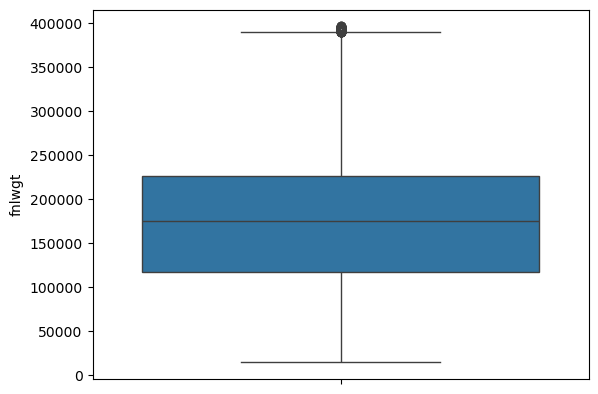

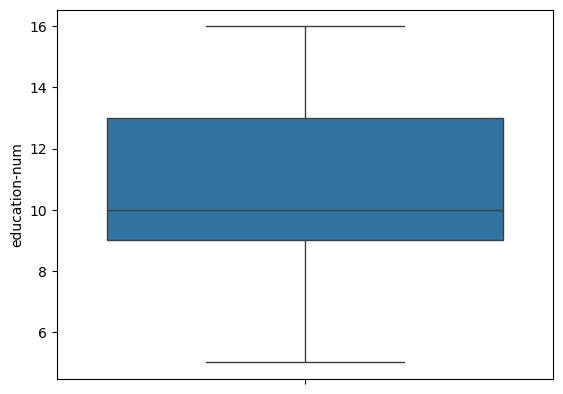

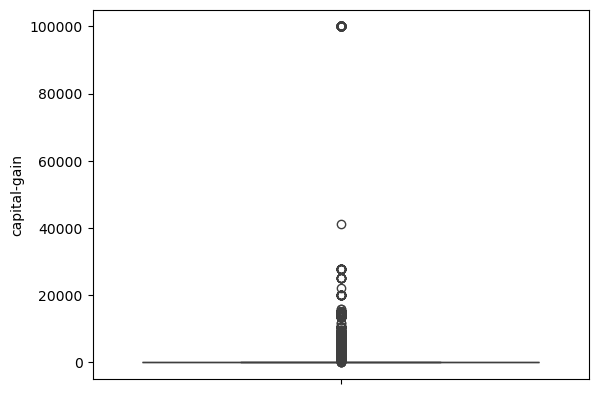

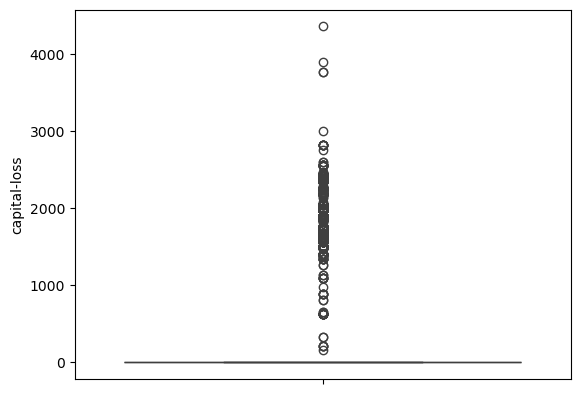

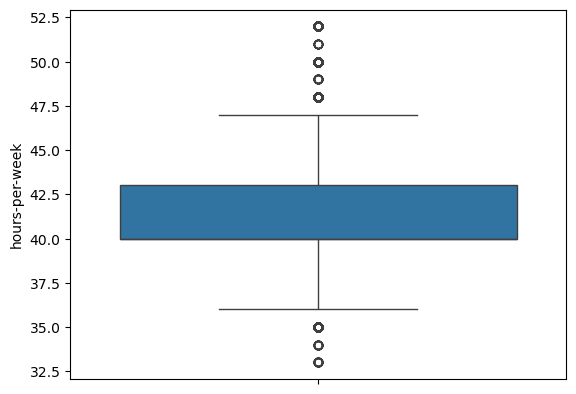

In [100]:
for col in df.columns:
    if df[col].dtype != 'object':
        sns.boxplot(df[col])
        plt.show()

In [90]:
col_outliers=['age','fnlwgt','education-num','hours-per-week']
for col in col_outliers:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-(1.5*IQR)
    upper_bound=Q3+(1.5*IQR)
    df=df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]

In [92]:
df.shape

(21722, 15)

In [96]:
from sklearn.preprocessing import LabelEncoder

In [98]:
le=LabelEncoder()

In [102]:
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=le.fit_transform(df[col])

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21722 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             21722 non-null  int64
 1   workclass       21722 non-null  int32
 2   fnlwgt          21722 non-null  int64
 3   education       21722 non-null  int32
 4   education-num   21722 non-null  int64
 5   marital-status  21722 non-null  int32
 6   occupation      21722 non-null  int32
 7   relationship    21722 non-null  int32
 8   race            21722 non-null  int32
 9   sex             21722 non-null  int32
 10  capital-gain    21722 non-null  int64
 11  capital-loss    21722 non-null  int64
 12  hours-per-week  21722 non-null  int64
 13  native-country  21722 non-null  int32
 14  annual_income   21722 non-null  int32
dtypes: int32(9), int64(6)
memory usage: 1.9 MB


In [109]:
x=df.drop('annual_income',axis=1)
y=df['annual_income']

In [111]:
x

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,6,77516,6,13,4,0,1,4,1,2174,0,40,38
2,38,3,215646,8,9,0,5,1,4,1,0,0,40,38
3,53,3,234721,1,7,2,5,0,2,1,0,0,40,38
4,28,3,338409,6,13,2,9,5,2,0,0,0,40,4
5,37,3,284582,9,14,2,3,5,4,0,0,0,40,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,22,3,310152,11,10,4,10,1,4,1,0,0,40,38
32556,27,3,257302,4,12,2,12,5,4,0,0,0,38,38
32557,40,3,154374,8,9,2,6,0,4,1,0,0,40,38
32558,58,3,151910,8,9,6,0,4,4,0,0,0,40,38


In [113]:
y

0        0
2        0
3        0
4        0
5        0
        ..
32555    0
32556    0
32557    1
32558    0
32560    1
Name: annual_income, Length: 21722, dtype: int32

In [115]:
from sklearn.model_selection import train_test_split

In [117]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42) # random state for selecting same data set everytime(consistency).

In [119]:
from sklearn.linear_model import LogisticRegression

In [123]:
model_lr=LogisticRegression()

In [125]:
model_lr.fit(x_train,y_train)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [127]:
y_pred=model_lr.predict(x_test)

In [131]:
from sklearn.metrics import *

In [137]:
accuracy_score(y_test,y_pred)*100

78.34292289988493

In [139]:
from sklearn.tree import DecisionTreeClassifier

In [141]:
dtc=DecisionTreeClassifier()

In [145]:
dtc.fit(x_train,y_train)

DecisionTreeClassifier()

In [161]:
y_pred1=dtc.predict(x_test)

In [171]:
accuracy_score(y_pred1,y_test)*100

79.07940161104719

In [155]:
from sklearn.ensemble import RandomForestClassifier

In [157]:
rfc=RandomForestClassifier()

In [159]:
rfc.fit(x_train,y_train)

RandomForestClassifier()

In [165]:
y_pred2=rfc.predict(x_test)

In [169]:
accuracy_score(y_test,y_pred2)*100


84.00460299194476

In [175]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=5)
grid_search.fit(x_train, y_train)
print(grid_search.best_params_)

{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


In [177]:
# We use GridSearchCV with Random Forest to automatically find the best combination of hyperparameters that gives the highest model performance 
# — instead of manually trying different values.

In [179]:
rfc1=RandomForestClassifier(max_depth= 20, min_samples_split= 5, n_estimators= 100)
rfc1.fit(x_train,y_train)


RandomForestClassifier(max_depth=20, min_samples_split=5)

In [181]:
y_pred3=rfc1.predict(x_test)

In [183]:
accuracy_score(y_test,y_pred3)*100

84.57997698504028